# Import Libs

In [37]:
import polars as pl
import polars.selectors as cs
import numpy as np
import re
import matplotlib.pyplot as plt
import hdbscan
from hdbscan import prediction as hdbscan_pred

from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.model_selection import train_test_split

from collections import Counter

# Import Annotations

In [3]:
anno_1 = pl.read_csv("../../data/DEAM/static_annotations_averaged_songs_1_2000.csv")
anno_1 = anno_1.rename({col: col.strip() for col in anno_1.columns})

anno_2 = pl.read_csv("../../data/DEAM/static_annotations_averaged_songs_2000_2058.csv")
anno_2 = anno_2.rename({col: col.strip() for col in anno_2.columns})

anno_1.shape, anno_2.shape

((1744, 5), (58, 13))

In [4]:
display(anno_1, anno_2)

song_id,valence_mean,valence_std,arousal_mean,arousal_std
i64,f64,f64,f64,f64
2,3.1,0.94,3.0,0.63
3,3.5,1.75,3.3,1.62
4,5.7,1.42,5.5,1.63
5,4.4,2.01,5.3,1.85
7,5.8,1.47,6.4,1.69
…,…,…,…,…
1996,3.9,1.87,5.9,2.21
1997,5.3,1.42,3.9,1.14
1998,6.4,1.5,6.2,1.6


song_id,valence_mean,valence_std,valence_ max_mean,valence_max_std,valence_min_mean,valence_min_std,arousal_mean,arousal_std,arousal_max_mean,arousal_max_std,arousal_min_mean,arousal_min_std
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2001,3.2,0.98,5.0,1.41,2.2,0.98,6.6,0.8,8.6,0.49,3.4,1.02
2002,6.4,0.49,8.2,0.98,5.0,1.1,5.2,1.17,7.4,1.36,2.2,1.17
2003,5.4,1.5,7.2,1.17,3.4,1.02,4.6,1.85,6.2,2.04,1.4,0.49
2004,5.0,1.1,6.4,1.02,3.2,1.17,4.8,1.6,6.0,2.28,2.8,0.98
2005,3.8,1.17,5.0,1.1,1.6,0.8,5.2,0.75,8.4,0.8,2.0,1.1
…,…,…,…,…,…,…,…,…,…,…,…,…
2054,5.4,1.2,6.0,1.1,4.4,1.36,3.6,1.36,4.2,1.33,2.4,0.8
2055,5.0,1.41,6.0,1.41,4.2,1.33,5.2,1.47,6.4,1.62,4.0,1.41
2056,5.0,1.41,5.6,1.62,4.4,1.36,4.6,1.74,5.0,1.79,4.0,1.67


In [5]:
all_annotations = pl.concat(
    [
        anno_1,
        anno_2.select(
            "song_id", "valence_mean", "valence_std", "arousal_mean", "arousal_std"
        ),
    ],
    how="vertical",
)


# Import Metadata

In [7]:
metadata_2013 = pl.read_csv("../../data/DEAM/metadata/metadata_2013.csv")
metadata_2014 = pl.read_csv(
    "../../data/DEAM/metadata/metadata_2014.csv", truncate_ragged_lines=True
)
metadata_2015 = pl.read_csv(
    "../../data/DEAM/metadata/metadata_2015.csv", truncate_ragged_lines=True
)

In [8]:
metadata_2013 = (
    metadata_2013.select("song_id", "Artist", "Song title", "Genre")
    .rename({"Artist": "artist", "Song title": "song_title", "Genre": "genre"})
    .with_columns(
        pl.col(pl.Utf8)
        .str.replace_all("\u00a0", " ")  # normalize non-breaking spaces if present
        .str.strip_chars()  # strip whitespace (space, tab, newline, etc.)
        .str.strip_chars('"')  # then strip leading/trailing double quotes
    )
)

In [9]:
metadata_2014 = (
    metadata_2014.select("Id", "Artist", "Track", "Genre")
    .rename(
        {
            "Id": "song_id",
            "Artist": "artist",
            "Track": "song_title",
            "Genre": "genre",
        }
    )
    .with_columns(
        pl.col(pl.Utf8)
        .str.replace_all("\u00a0", " ")  # normalize non-breaking spaces if present
        .str.strip_chars()  # strip whitespace (space, tab, newline, etc.)
        .str.strip_chars('"')  # then strip leading/trailing double quotes
    )
)

In [10]:
metadata_2015 = (
    metadata_2015.select("id", "artist", "title", "genre")
    .rename(
        {
            "id": "song_id",
            "title": "song_title",
        }
    )
    .with_columns(
        pl.col(pl.Utf8)
        .str.replace_all("\u00a0", " ")  # normalize non-breaking spaces if present
        .str.strip_chars()  # strip whitespace (space, tab, newline, etc.)
        .str.strip_chars('"')  # then strip leading/trailing double quotes
    )
)

In [11]:
all_metadata = pl.concat(
    [metadata_2013, metadata_2014, metadata_2015],
    how="vertical",
)

all_metadata

song_id,artist,song_title,genre
i64,str,str,str
2,"""The New Mystikal Troubadours""","""Tonight A Lonely Century""","""Blues"""
3,"""Kevin MacLeod""","""DD Groove""","""Blues"""
4,"""Kevin MacLeod""","""Slow Burn""","""Blues"""
5,"""My Bubba & Mi""","""Nothing Much""","""Blues"""
7,"""Kevin MacLeod""","""Hustle""","""Blues"""
…,…,…,…
2054,"""Tom La Meche""","""Interlude""","""jazz"""
2055,"""Goo Goo Cluster""","""Vide grenier""","""reggae"""
2056,"""Ruediger Kramer""","""happy child singing""","""jazz"""


# Join Annotations & Metadata

In [12]:
annot_meta = all_annotations.join(all_metadata, on="song_id", how="left").with_columns(
    pl.col("genre").str.to_lowercase().alias("genre")
)
annot_meta

song_id,valence_mean,valence_std,arousal_mean,arousal_std,artist,song_title,genre
i64,f64,f64,f64,f64,str,str,str
2,3.1,0.94,3.0,0.63,"""The New Mystikal Troubadours""","""Tonight A Lonely Century""","""blues"""
3,3.5,1.75,3.3,1.62,"""Kevin MacLeod""","""DD Groove""","""blues"""
4,5.7,1.42,5.5,1.63,"""Kevin MacLeod""","""Slow Burn""","""blues"""
5,4.4,2.01,5.3,1.85,"""My Bubba & Mi""","""Nothing Much""","""blues"""
7,5.8,1.47,6.4,1.69,"""Kevin MacLeod""","""Hustle""","""blues"""
…,…,…,…,…,…,…,…
2054,5.4,1.2,3.6,1.36,"""Tom La Meche""","""Interlude""","""jazz"""
2055,5.0,1.41,5.2,1.47,"""Goo Goo Cluster""","""Vide grenier""","""reggae"""
2056,5.0,1.41,4.6,1.74,"""Ruediger Kramer""","""happy child singing""","""jazz"""


# Consolidating Genres to 9 Categories

In [13]:
unique_genres = annot_meta.select("genre").unique().get_column("genre").to_list()

In [14]:
# 10 umbrella bins
UMBRELLAS = [
    "rock",
    "pop",
    "hip-hop",
    "electronic",
    "jazz",
    "classical",
    "folk/country",
    "blues/soul",
    "world",
    "other",
]


In [15]:
KEYWORD_TO_BIN = {
    # core
    "rock": "rock",
    "pop": "pop",
    "hip-hop": "hip-hop",
    "hiphop": "hip-hop",
    "rap": "hip-hop",
    "electronic": "electronic",
    "jazz": "jazz",
    "classical": "classical",
    "folk": "folk/country",
    "country": "folk/country",
    "blues": "blues/soul",
    "soulrb": "blues/soul",
    "soul": "blues/soul",
    "world": "world",
    "reggae": "world",
    # helpful hints -> fold into umbrellas
    "acoustic": "folk/country",
    "singer/songwriter": "folk/country",
    "singersongwriter": "folk/country",  # just in case
    # noise/modifiers (we won’t map these; leave here for clarity):
    # "experimental", "instrumental", "international", "spoken", "fusion"
}

# If multiple umbrellas tie, prefer earlier in this list:
TIE_BREAK_PRIORITY = [
    "hip-hop",
    "rock",
    "pop",
    "electronic",
    "jazz",
    "classical",
    "folk/country",
    "blues/soul",
    "world",
    "other",
]

NOISE_WORDS = {
    "experimental",
    "instrumental",
    "international",
    "spoken",
    "fusion",
    "n/a",
}


In [16]:
def normalize_text(s: str) -> str:
    s = (s or "").strip().lower()
    # standardize separators
    s = s.replace("/", "-")
    # compress whitespace and dashes
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"-+", "-", s)
    return s


def classify_genre(raw: str) -> str:
    s = normalize_text(raw)

    if not s or s in NOISE_WORDS or s == "n/a":
        return "other"

    votes = Counter()

    # substring voting
    for kw, bin_name in KEYWORD_TO_BIN.items():
        if kw in s:
            votes[bin_name] += 1

    # if no keywords matched, try token-wise fallback
    if not votes:
        tokens = re.split(r"[-\s]+", s)
        tokens = [t for t in tokens if t and t not in NOISE_WORDS]
        for t in tokens:
            bin_name = KEYWORD_TO_BIN.get(t)
            if bin_name:
                votes[bin_name] += 1

    if not votes:
        # final fallback: heuristic keywords
        if "groove" in s or "bird of youth" in s:
            return "other"
        return "other"

    # choose the umbrella with max votes; break ties by priority
    top_count = max(votes.values())
    candidates = [b for b, c in votes.items() if c == top_count]
    for pref in TIE_BREAK_PRIORITY:
        if pref in candidates:
            return pref
    return "other"


In [18]:
collapsed = [classify_genre(g) for g in unique_genres]
for g, c in zip(unique_genres, collapsed):
    print(f"{g:60s} -> {c}")


international-pop-rock                                       -> rock
folk-rock                                                    -> rock
soulrb-electronic                                            -> blues/soul
soulrb-blues-international-electronic                        -> blues/soul
electronic                                                   -> electronic
reggae                                                       -> world
country-pop-rock                                             -> rock
classical-instrumental-electronic                            -> electronic
country-experimental-rock                                    -> rock
international-experimental-rock                              -> rock
soulrb-blues-jazz                                            -> blues/soul
international-folk                                           -> folk/country
folk-pop-experimental                                        -> pop
hip-hop-instrumental                                         -> h

In [19]:
merged_genres = annot_meta.with_columns(
    pl.col("genre").map_elements(classify_genre, return_dtype=pl.String).alias("genre")
).with_columns(
    pl.when(pl.col("genre") == "world")
    .then(pl.lit("other"))
    .otherwise(pl.col("genre"))
    .alias("genre")
)

merged_genres

song_id,valence_mean,valence_std,arousal_mean,arousal_std,artist,song_title,genre
i64,f64,f64,f64,f64,str,str,str
2,3.1,0.94,3.0,0.63,"""The New Mystikal Troubadours""","""Tonight A Lonely Century""","""blues/soul"""
3,3.5,1.75,3.3,1.62,"""Kevin MacLeod""","""DD Groove""","""blues/soul"""
4,5.7,1.42,5.5,1.63,"""Kevin MacLeod""","""Slow Burn""","""blues/soul"""
5,4.4,2.01,5.3,1.85,"""My Bubba & Mi""","""Nothing Much""","""blues/soul"""
7,5.8,1.47,6.4,1.69,"""Kevin MacLeod""","""Hustle""","""blues/soul"""
…,…,…,…,…,…,…,…
2054,5.4,1.2,3.6,1.36,"""Tom La Meche""","""Interlude""","""jazz"""
2055,5.0,1.41,5.2,1.47,"""Goo Goo Cluster""","""Vide grenier""","""other"""
2056,5.0,1.41,4.6,1.74,"""Ruediger Kramer""","""happy child singing""","""jazz"""


In [20]:
merged_genres["genre"].value_counts(sort=True)

genre,count
str,u32
"""rock""",378
"""folk/country""",320
"""electronic""",242
"""blues/soul""",205
"""classical""",180
"""jazz""",171
"""pop""",170
"""hip-hop""",110
"""other""",26


# Scale Alignment

In [21]:
merged_genres = merged_genres.with_columns(
    ((pl.col("valence_mean") - 5.0) / 4.0).clip(-1.0, 1.0).alias("valence_ref"),
    ((pl.col("arousal_mean") - 5.0) / 4.0).clip(-1.0, 1.0).alias("arousal_ref"),
)

In [22]:
merged_genres.select(
    "valence_ref", "arousal_ref", "valence_mean", "arousal_mean"
).describe()

statistic,valence_ref,arousal_ref,valence_mean,arousal_mean
str,f64,f64,f64,f64
"""count""",1802.0,1802.0,1802.0,1802.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",-0.023964,-0.046493,4.904145,4.814029
"""std""",0.29356,0.320547,1.17424,1.282187
"""min""",-0.85,-0.85,1.6,1.6
"""25%""",-0.225,-0.3,4.1,3.8
"""50%""",-0.025,-0.025,4.9,4.9
"""75%""",0.2,0.2,5.8,5.8
"""max""",0.85,0.775,8.4,8.1


In [23]:
merged_genres.select(
    "song_id", "valence_ref", "arousal_ref", "artist", "song_title", "genre"
)

song_id,valence_ref,arousal_ref,artist,song_title,genre
i64,f64,f64,str,str,str
2,-0.475,-0.5,"""The New Mystikal Troubadours""","""Tonight A Lonely Century""","""blues/soul"""
3,-0.375,-0.425,"""Kevin MacLeod""","""DD Groove""","""blues/soul"""
4,0.175,0.125,"""Kevin MacLeod""","""Slow Burn""","""blues/soul"""
5,-0.15,0.075,"""My Bubba & Mi""","""Nothing Much""","""blues/soul"""
7,0.2,0.35,"""Kevin MacLeod""","""Hustle""","""blues/soul"""
…,…,…,…,…,…
2054,0.1,-0.35,"""Tom La Meche""","""Interlude""","""jazz"""
2055,0.0,0.05,"""Goo Goo Cluster""","""Vide grenier""","""other"""
2056,0.0,-0.1,"""Ruediger Kramer""","""happy child singing""","""jazz"""


# Data Preprocessing

In [24]:
deam_base = merged_genres.drop_nulls(
    ["valence_ref", "arousal_ref", "genre"]
)  # Not over-engineered: reuses prior aggregation instead of introducing extra joins.
df_pl = deam_base.select(["valence_ref", "arousal_ref", "genre"])
song_ids = deam_base["song_id"].to_list()
artists = deam_base["artist"].to_list()
song_titles = deam_base["song_title"].to_list()
X = df_pl.select(["valence_ref", "arousal_ref"]).to_numpy()
genres = df_pl["genre"].to_list()

scaler = StandardScaler().fit(X)
Xs = scaler.transform(X)

Xtr, Xte = train_test_split(Xs, test_size=0.2, random_state=2025, shuffle=True)


# Gaussian Mixture Model (GMM)

A GMM assumes the data are generated from a mixture of multivariate Gaussians. 
Each component has a mean and covariance, and we fit them by maximizing likelihood.   

Compared to k-means, GMMs 
+ produce soft assignments (posterior probabilities per cluster), and
+ can model elliptical clusters via full or diagonal covariances.   

They’re a better match for valence–arousal ellipses than k-means’ spherical assumption.

## Model selection by BIC

**Bayesian Information Criterion (BIC) for GMMs** 
 
BIC trades off model fit (log-likelihood) and complexity (number of free parameters). For GMMs, lower BIC typically selects a reasonable number of components K and covariance structure.

In [25]:
best, best_bic = None, np.inf
for cov in ("full", "diag"):
    for K in range(5, 13):  # keep your original K-range (or widen later)
        m = GaussianMixture(
            n_components=K, covariance_type=cov, n_init=10, random_state=2025
        ).fit(Xtr)  # CHANGED: fit on Xtr
        bic = m.bic(Xtr)  # CHANGED: BIC on Xtr
        if bic < best_bic:
            best_bic, best = bic, m

gm = best

# For interpretation/plots, keep full-data predictions:
labels = gm.predict(Xs)
proba = gm.predict_proba(Xs)


In [26]:
gm, labels, proba

(GaussianMixture(covariance_type='diag', n_components=5, n_init=10,
                 random_state=2025),
 array([1, 1, 2, ..., 2, 3, 3], shape=(1802,)),
 array([[6.50058540e-15, 9.37551562e-01, 1.13203431e-07, 2.25830126e-02,
         3.98653119e-02],
        [3.13305107e-12, 8.55982293e-01, 6.32762795e-06, 6.14772583e-02,
         8.25341211e-02],
        [8.56025305e-02, 4.68721041e-05, 8.59462495e-01, 3.02229227e-02,
         2.46651795e-02],
        ...,
        [5.48961200e-04, 2.70973420e-02, 3.46947232e-01, 3.01739281e-01,
         3.23667183e-01],
        [2.73321142e-07, 4.14847535e-06, 2.57518384e-03, 9.96203698e-01,
         1.21669649e-03],
        [8.82164738e-06, 7.92678357e-04, 4.97782430e-02, 9.26942090e-01,
         2.24781671e-02]], shape=(1802, 5)))

## Evaluate Clusters

**Silhouette score** 

+ Silhouette compares how close a point is to its own cluster vs. the nearest other cluster.   
+ It ranges from −1 to 1.   
+ Values > 0.5 suggest strong structure, ~0.25–0.5 suggest reasonable structure, and ≤ 0 indicate overlapping or wrong assignments.   
+ Our 0.3 indicates moderately separated clusters.

**Davies–Bouldin index**  

+ DB measures the average similarity between each cluster and its most similar neighbor; lower is better. 
+ Values < 1 generally indicate compact, well-separated clusters. 
+ Ours is 0.920 → healthy separation.

**Calinski–Harabasz index** 
  
+ CH is the ratio of between-cluster dispersion to within-cluster dispersion; higher is better. 
+ It tends to grow with clearer separation and more compact clusters. 
+ Because it’s unbounded, we compare it across candidate solutions rather than interpret it absolutely.

**Posterior entropy (soft assignment uncertainty)**  

+ Given the per-cluster posteriors for a point, entropy summarizes how confident the model is. 
+ Entropy is 0 for a crisp assignment (one posterior ≈1) and higher when probability mass is spread. 
+ Reporting mean entropy (and its distribution per cluster) helps identify borderline vs core points.

In [27]:
# --- held-out log-likelihood ---
train_ll = gm.score(Xtr)  # average log-likelihood on TRAIN
test_ll = gm.score(Xte)  # average log-likelihood on TEST

labels_tr_pred = gm.predict(Xtr)
labels_te_pred = gm.predict(Xte)


def _compute_geom_metrics(X, cluster_labels):
    uniq = np.unique(cluster_labels)
    if uniq.size < 2:
        return {"sil": None, "db": None, "ch": None}
    metrics = {}
    for key, func in (
        ("sil", silhouette_score),
        ("db", davies_bouldin_score),
        ("ch", calinski_harabasz_score),
    ):
        try:
            metrics[key] = float(func(X, cluster_labels))
        except ValueError:
            metrics[key] = None
    return metrics


geom_metrics = {
    "train": _compute_geom_metrics(Xtr, labels_tr_pred),
    "test": _compute_geom_metrics(Xte, labels_te_pred),
    "full": _compute_geom_metrics(Xs, labels),
}

sil = geom_metrics["full"]["sil"]
sil_tr = geom_metrics["train"]["sil"]
sil_te = geom_metrics["test"]["sil"]
db_tr = geom_metrics["train"]["db"]
db_te = geom_metrics["test"]["db"]
ch_tr = geom_metrics["train"]["ch"]
ch_te = geom_metrics["test"]["ch"]

In [28]:
entropy_full = (-(proba * np.log(proba + 1e-12)).sum(axis=1)).mean()

proba_tr = gm.predict_proba(Xtr)
entropy_train = (-(proba_tr * np.log(proba_tr + 1e-12)).sum(axis=1)).mean()
proba_te = gm.predict_proba(Xte)
entropy_test = (-(proba_te * np.log(proba_te + 1e-12)).sum(axis=1)).mean()

entropy_stats = {
    "full": float(entropy_full),
    "train": float(entropy_train),
    "test": float(entropy_test),
}

db = geom_metrics["full"]["db"]
ch = geom_metrics["full"]["ch"]
entropy = entropy_stats["full"]
entropy_te = entropy_stats["test"]

In [29]:
eval_pl = pl.DataFrame(
    {
        "cluster": labels,
        "genre": genres,
    }
)

ct = (
    eval_pl.group_by(["cluster", "genre"])
    .len()
    .pivot(values="len", index="cluster", on="genre")
    .fill_null(0)
    .sort("cluster")
)

ct

cluster,blues/soul,hip-hop,rock,jazz,electronic,other,pop,folk/country,classical
i64,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,31,8,60,26,42,2,31,46,6
1,47,6,62,45,74,6,34,94,96
2,60,64,133,46,72,11,55,80,18
3,42,21,79,32,29,2,28,63,53
4,25,11,44,22,25,5,22,37,7


Purity per cluster = max genre count / total in that cluster

> “Purity ≈ 0.2–0.25: what that says about genre vs. emotion”

Purity here is “most common genre in a cluster / cluster size.” Low purity is expected: high-level genre labels don’t map one-to-one with affect. It’s normal to see mixed genres in the same emotional region (e.g., “upbeat + energetic” can be rock or electronic).

In [30]:
purity_df = (
    ct.with_columns(
        [
            pl.sum_horizontal(pl.all().exclude("cluster")).alias("total"),
            pl.max_horizontal(pl.all().exclude("cluster")).alias("max_cnt"),
        ]
    )
    .with_columns((pl.col("max_cnt") / pl.col("total")).alias("purity"))
    .select(["cluster", "purity"])
)

purity_df

cluster,purity
i64,f64
0,0.238095
1,0.206897
2,0.246753
3,0.226361
4,0.222222


In [32]:
top3_df = (
    eval_pl.group_by(["cluster", "genre"])
    .len()
    .sort(["cluster", "len"], descending=[False, True])
    .group_by("cluster")
    .agg(
        [
            pl.col("genre").head(3).alias("top_genres"),
            pl.col("len").head(3).alias("top_counts"),
        ]
    )
)

# Cluster centers (back in original valence/arousal space)
centers_orig = scaler.inverse_transform(gm.means_)
center_map = {
    i: (centers_orig[i, 0], centers_orig[i, 1]) for i in range(centers_orig.shape[0])
}

# Pretty print summary
purity_map = dict(zip(purity_df["cluster"].to_list(), purity_df["purity"].to_list()))
cluster_sizes = dict(zip(*np.unique(labels, return_counts=True)))

cluster_rows = []
for row in top3_df.iter_rows(named=True):
    cid = int(row["cluster"])
    top = dict(zip(row["top_genres"], row["top_counts"]))
    cx, cy = center_map[cid]
    cluster_rows.append(
        {
            "cluster_id": cid,
            "purity": float(purity_map[cid]),
            "center_valence": float(cx),
            "center_arousal": float(cy),
            "top_genres": top,
            "n_points": int(cluster_sizes.get(cid, 0)),
        }
    )

cluster_rows = sorted(cluster_rows, key=lambda r: r["cluster_id"])

In [29]:
def _fmt_metric(val, pattern="{:.3f}"):
    return pattern.format(val) if val is not None else "n/a"


def _fmt_center(v, a):
    return f"({v:+.2f}, {a:+.2f})"


def _fmt_noise_fraction():
    return "0.00%"


print("GMM clustering summary")
print(f"- total points: {Xs.shape[0]}")
print(f"- clusters (excl. noise): {gm.n_components}")
print(f"- noise fraction: {_fmt_noise_fraction()}")

print(
    "Full data → silhouette={sil} | davies-bouldin={db} | calinski-harabasz={ch} | avg posterior entropy={entropy}".format(
        sil=_fmt_metric(geom_metrics["full"]["sil"]),
        db=_fmt_metric(geom_metrics["full"]["db"]),
        ch=_fmt_metric(geom_metrics["full"]["ch"], "{:.1f}"),
        entropy=_fmt_metric(entropy_stats["full"]),
    )
)

print(
    "Train       → silhouette={sil} | DB={db} | CH={ch}".format(
        sil=_fmt_metric(geom_metrics["train"]["sil"]),
        db=_fmt_metric(geom_metrics["train"]["db"]),
        ch=_fmt_metric(geom_metrics["train"]["ch"], "{:.1f}"),
    )
)

print(
    "Test        → silhouette={sil} | DB={db} | CH={ch} | avg posterior entropy={entropy}".format(
        sil=_fmt_metric(geom_metrics["test"]["sil"]),
        db=_fmt_metric(geom_metrics["test"]["db"]),
        ch=_fmt_metric(geom_metrics["test"]["ch"], "{:.1f}"),
        entropy=_fmt_metric(entropy_stats["test"]),
    )
)

for row in cluster_rows:
    print(
        f"cluster {row['cluster_id']}: "
        f"purity={row['purity']:.2f} | "
        f"center={_fmt_center(row['center_valence'], row['center_arousal'])} | "
        f"top_genres={row['top_genres']}"
    )

if cluster_rows:
    wavg_purity = np.average(
        [r["purity"] for r in cluster_rows],
        weights=[r["n_points"] for r in cluster_rows],
    )
    print(f"Weighted avg. purity (excl. noise): {wavg_purity:.3f}")

GMM clustering summary
- total points: 1802
- clusters (excl. noise): 5
- noise fraction: 0.00%
Full data → silhouette=0.325 | davies-bouldin=0.899 | calinski-harabasz=1538.6 | avg posterior entropy=0.686
Train       → silhouette=0.329 | DB=0.897 | CH=1237.7
Test        → silhouette=0.302 | DB=0.920 | CH=300.8 | avg posterior entropy=0.691
cluster 0: purity=0.24 | center=(+0.37, +0.33) | top_genres={'rock': 60, 'folk/country': 46, 'electronic': 42}
cluster 1: purity=0.21 | center=(-0.31, -0.43) | top_genres={'classical': 96, 'folk/country': 94, 'electronic': 74}
cluster 2: purity=0.25 | center=(+0.11, +0.14) | top_genres={'rock': 133, 'folk/country': 80, 'electronic': 72}
cluster 3: purity=0.23 | center=(-0.20, -0.01) | top_genres={'rock': 79, 'folk/country': 63, 'classical': 53}
cluster 4: purity=0.22 | center=(+0.01, -0.24) | top_genres={'rock': 44, 'folk/country': 37, 'blues/soul': 25}
Weighted avg. purity (excl. noise): 0.229


In [30]:
print(f"K={gm.n_components}, cov={gm.covariance_type}")
print(f"BIC={best_bic:.1f} | train_LL={train_ll:.3f} | test_LL={test_ll:.3f}")

print("converged:", gm.converged_, "| iters:", gm.n_iter_)
# check smallest eigenvalue across components (standardized space)


def min_eigvals(gm):
    if gm.covariance_type == "full":
        return min(np.linalg.eigvalsh(S).min() for S in gm.covariances_)
    elif gm.covariance_type == "diag":
        return float(np.min(gm.covariances_))
    else:  # 'tied' or 'spherical' if you ever use them
        return float(np.min(gm.covariances_))


print("min eigenvalue:", min_eigvals(gm))

K=5, cov=diag
BIC=7608.4 | train_LL=-2.579 | test_LL=-2.626
converged: True | iters: 8
min eigenvalue: 0.21335847523325988


## Plot clusters in valence-arousal space

Quadrant counts (overall): Q1=647, Q2=229, Q3=686, Q4=240
Cluster 0 quadrant counts: Q1=251, Q2=0, Q3=0, Q4=1
Cluster 1 quadrant counts: Q1=0, Q2=0, Q3=454, Q4=10
Cluster 2 quadrant counts: Q1=396, Q2=68, Q3=5, Q4=70
Cluster 3 quadrant counts: Q1=0, Q2=161, Q3=188, Q4=0
Cluster 4 quadrant counts: Q1=0, Q2=0, Q3=39, Q4=159


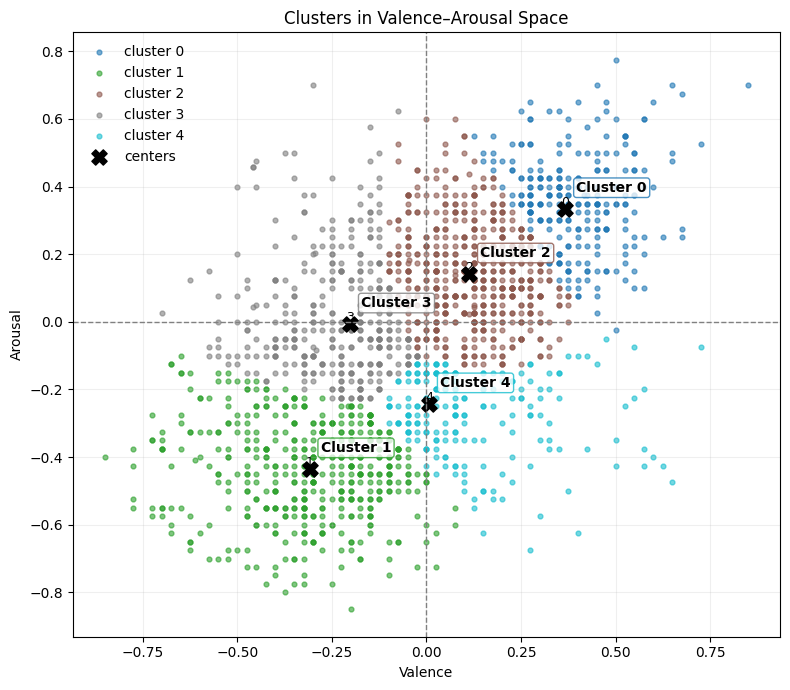

In [31]:
K = gm.n_components
colors = (
    plt.cm.tab10(np.linspace(0, 1, K))
    if K <= 10
    else plt.cm.nipy_spectral(np.linspace(0, 1, K))
)

plt.figure(figsize=(8, 7))
for k in range(K):
    mask = labels == k
    plt.scatter(
        X[mask, 0], X[mask, 1], s=12, alpha=0.6, color=colors[k], label=f"cluster {k}"
    )

# centers (in original space)
plt.scatter(
    centers_orig[:, 0],
    centers_orig[:, 1],
    c="black",
    s=120,
    marker="X",
    label="centers",
)

# add "Cluster k" annotations near each center
for k, (cx, cy) in enumerate(centers_orig):
    plt.annotate(
        f"Cluster {k}",
        xy=(cx, cy),
        xytext=(8, 10),  # offset to avoid overlapping the 'X'
        textcoords="offset points",
        ha="left",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="black",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[k], alpha=0.8),
    )

for i, (cx, cy) in enumerate(centers_orig):
    plt.text(cx, cy, str(i), color="black", fontsize=9, ha="center", va="bottom")

# quadrant lines
plt.axvline(0, color="gray", lw=1, ls="--")
plt.axhline(0, color="gray", lw=1, ls="--")
plt.xlabel("Valence")
plt.ylabel("Arousal")
plt.title("Clusters in Valence–Arousal Space")
plt.legend(loc="best", frameon=False)
plt.grid(alpha=0.2)

# quadrant distribution (overall and per-cluster)
q1 = int(np.sum((X[:, 0] >= 0) & (X[:, 1] >= 0)))
q2 = int(np.sum((X[:, 0] < 0) & (X[:, 1] >= 0)))
q3 = int(np.sum((X[:, 0] < 0) & (X[:, 1] < 0)))
q4 = int(np.sum((X[:, 0] >= 0) & (X[:, 1] < 0)))
print(f"Quadrant counts (overall): Q1={q1}, Q2={q2}, Q3={q3}, Q4={q4}")
for k in range(K):
    Xm = X[labels == k]
    q1k = int(np.sum((Xm[:, 0] >= 0) & (Xm[:, 1] >= 0)))
    q2k = int(np.sum((Xm[:, 0] < 0) & (Xm[:, 1] >= 0)))
    q3k = int(np.sum((Xm[:, 0] < 0) & (Xm[:, 1] < 0)))
    q4k = int(np.sum((Xm[:, 0] >= 0) & (Xm[:, 1] < 0)))
    print(f"Cluster {k} quadrant counts: Q1={q1k}, Q2={q2k}, Q3={q3k}, Q4={q4k}")

plt.tight_layout()
plt.show()

The emotion landscape is not genre-pure: every cluster mixes many genres, and purity ≈0.2–0.25 across the board.

There are two distinct positive–energetic regions (k=0 mild, k=2 strong), and two negative–low-arousal regions (k=3 pronounced, k=1 milder/tenser). A near-neutral/low-arousal region (k=4) rounds out the five.

The metrics (Silhouette ~0.32, DB ~0.92) are consistent with real, moderately distinct structure in valence–arousal space; not perfectly separable (expected for affect data), but useful.

## Export GMM Clusters

In [32]:
deam_gmm_clusters = df_pl.with_columns(
    [
        pl.Series("cluster", labels),
        pl.Series("cluster_conf", proba.max(axis=1)),
        pl.Series("song_id", song_ids),
        pl.Series("artist", artists),
        pl.Series("song_title", song_titles),
    ]
)
deam_gmm_clusters.head()

valence_ref,arousal_ref,genre,cluster,cluster_conf,song_id,artist,song_title
f64,f64,str,i64,f64,i64,str,str
-0.475,-0.5,"""blues/soul""",1,0.937552,2,"""The New Mystikal Troubadours""","""Tonight A Lonely Century"""
-0.375,-0.425,"""blues/soul""",1,0.855982,3,"""Kevin MacLeod""","""DD Groove"""
0.175,0.125,"""blues/soul""",2,0.859462,4,"""Kevin MacLeod""","""Slow Burn"""
-0.15,0.075,"""blues/soul""",3,0.650001,5,"""My Bubba & Mi""","""Nothing Much"""
0.2,0.35,"""blues/soul""",2,0.555054,7,"""Kevin MacLeod""","""Hustle"""


In [33]:
deam_gmm_clusters["cluster"].value_counts()

cluster,count
i64,u32
1,464
4,198
2,539
0,252
3,349


In [34]:
alignment_reference = pl.DataFrame(
    {
        "row_idx": pl.arange(0, len(song_ids), eager=True),
        "song_id_expected": song_ids,
        "artist_expected": artists,
        "song_title_expected": song_titles,
    }
)

alignment_issues = (
    deam_gmm_clusters.with_row_index("row_idx")
    .join(alignment_reference, on="row_idx", how="left")
    .filter(
        (pl.col("song_id") != pl.col("song_id_expected"))
        | (pl.col("artist") != pl.col("artist_expected"))
        | (pl.col("song_title") != pl.col("song_title_expected"))
    )
)
assert alignment_issues.is_empty(), alignment_issues.head()


In [ ]:
deam_gmm_clusters_path = "artifacts/deam_gmm/deam_gmm_clusters.csv"
deam_gmm_clusters.write_csv(deam_gmm_clusters_path)
print(f"SAVED DEAM GMM CLUSTERS → {deam_gmm_clusters_path}")

# HDBSCAN

In [36]:
Xtr, Xte, genres_tr, genres_te = train_test_split(
    Xs, genres, test_size=0.2, random_state=2025, shuffle=True
)
Gtr = np.array(genres_tr)
Gte = np.array(genres_te)

## Fit on Train

In [37]:
hdb = hdbscan.HDBSCAN(
    min_cluster_size=35,  # tune as needed
    min_samples=10,  # or an int (e.g. 10)
    metric="euclidean",
    prediction_data=True,  # required for approximate_predict on test
    cluster_selection_method="leaf",
).fit(Xtr)

labels_tr = hdb.labels_
probs_tr = hdb.probabilities_

labels_te, probs_te = hdbscan_pred.approximate_predict(hdb, Xte)

/opt/anaconda3/envs/P-SEM2/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/P-SEM2/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [38]:
X_all = np.vstack([Xtr, Xte])
labels_all = np.concatenate([labels_tr, labels_te])
genres_all = np.concatenate([Gtr, Gte])
non_noise = labels_all >= 0
uniq_cls = np.unique(labels_all[non_noise])
noise_frac = float(np.mean(labels_all == -1))

## Evaluate Clusters

In [39]:
def _compute_geom_metrics(X, labels):
    mask = labels >= 0
    if mask.sum() == 0:
        return {"sil": None, "db": None, "ch": None}
    uniq = np.unique(labels[mask])
    if uniq.size < 2:
        return {"sil": None, "db": None, "ch": None}
    X_use = X[mask]
    y_use = labels[mask]
    metrics = {}
    for key, func in (
        ("sil", silhouette_score),
        ("db", davies_bouldin_score),
        ("ch", calinski_harabasz_score),
    ):
        try:
            metrics[key] = float(func(X_use, y_use))
        except ValueError:
            metrics[key] = None
    return metrics


geom_metrics = {
    "full": _compute_geom_metrics(X_all, labels_all),
    "train": _compute_geom_metrics(Xtr, labels_tr),
    "test": _compute_geom_metrics(Xte, labels_te),
}


def _mean_entropy(memberships):
    memberships = np.asarray(memberships)
    if memberships.ndim == 1:
        memberships = memberships[None, :]
    if memberships.size == 0:
        return None
    noise_prob = np.clip(1.0 - memberships.sum(axis=1, keepdims=True), 0.0, 1.0)
    dist = np.hstack([memberships, noise_prob])
    if dist.shape[0] == 0:
        return None
    ent = -(dist * np.log(dist + 1e-12)).sum(axis=1)
    return float(np.mean(ent))


membership_train = np.asarray(hdbscan_pred.all_points_membership_vectors(hdb))
if membership_train.ndim == 1:
    membership_train = membership_train[None, :]
membership_test = np.asarray(hdbscan_pred.membership_vector(hdb, Xte))
if membership_test.ndim == 1:
    membership_test = membership_test[None, :]
if membership_test.size:
    membership_all = np.vstack([membership_train, membership_test])
else:
    membership_all = membership_train

entropy_stats = {
    "full": _mean_entropy(membership_all),
    "train": _mean_entropy(membership_train),
    "test": _mean_entropy(membership_test),
}

rows = []
for cid in sorted(uniq_cls):
    m = labels_all == cid
    Xi = X_all[m]
    center = Xi.mean(axis=0)
    cnts = Counter(genres_all[m])
    maj_label, maj_count = cnts.most_common(1)[0]
    purity = maj_count / m.sum()
    top3 = dict(cnts.most_common(3))

    rows.append(
        {
            "cluster_id": int(cid),
            "n_points": int(m.sum()),
            "center_valence": float(center[0]),
            "center_arousal": float(center[1]),
            "purity": float(purity),
            "majority_label": maj_label,
            "majority_count": int(maj_count),
            "top_genres": top3,
        }
    )

cluster_report_pl = pl.DataFrame(rows).sort("cluster_id")
sil = geom_metrics["full"]["sil"]
cluster_report_pl

cluster_id,n_points,center_valence,center_arousal,purity,majority_label,majority_count,top_genres
i64,i64,f64,f64,f64,str,i64,struct[6]
0,41,-0.009764,-0.878605,0.219512,"""folk/country""",9,"{9,8,6,null,null,null}"
1,62,-1.013387,-1.381212,0.241935,"""folk/country""",15,"{15,14,null,9,null,null}"
2,61,-0.504867,-1.305199,0.180328,"""blues/soul""",11,"{11,null,11,null,11,null}"
3,91,-0.626038,-0.595016,0.241758,"""rock""",22,"{17,22,null,17,null,null}"
4,412,0.418983,0.379425,0.259709,"""rock""",107,"{null,107,null,null,58,55}"
5,54,1.211146,1.285378,0.296296,"""rock""",16,"{null,16,10,null,9,null}"


In [40]:
def _fmt_metric(val, pattern="{:.3f}"):
    return pattern.format(val) if val is not None else "n/a"


def _fmt_center(v, a):
    return f"({v:+.2f}, {a:+.2f})"


full_metrics = geom_metrics["full"]
train_metrics = geom_metrics["train"]
test_metrics = geom_metrics["test"]

print("HDBSCAN clustering summary")
print(f"- total points: {X_all.shape[0]}")
print(f"- clusters (excl. noise): {uniq_cls.size}")
print(f"- noise fraction: {noise_frac:.2%}")

print(
    "Full data → silhouette={sil} | davies-bouldin={db} | calinski-harabasz={ch} | avg posterior entropy={entropy}".format(
        sil=_fmt_metric(full_metrics["sil"]),
        db=_fmt_metric(full_metrics["db"]),
        ch=_fmt_metric(full_metrics["ch"], "{:.1f}"),
        entropy=_fmt_metric(entropy_stats["full"]),
    )
)

if train_metrics["sil"] is not None:
    print(
        "Train       → silhouette={sil} | DB={db} | CH={ch}".format(
            sil=_fmt_metric(train_metrics["sil"]),
            db=_fmt_metric(train_metrics["db"]),
            ch=_fmt_metric(train_metrics["ch"], "{:.1f}"),
        )
    )
else:
    print("Train       → silhouette=n/a | DB=n/a | CH=n/a")

print(
    "Test        → silhouette={sil} | DB={db} | CH={ch} | avg posterior entropy={entropy}".format(
        sil=_fmt_metric(test_metrics["sil"]),
        db=_fmt_metric(test_metrics["db"]),
        ch=_fmt_metric(test_metrics["ch"], "{:.1f}"),
        entropy=_fmt_metric(entropy_stats["test"]),
    )
)

for r in rows:
    print(
        f"cluster {r['cluster_id']}: "
        f"purity={r['purity']:.2f} | "
        f"center={_fmt_center(r['center_valence'], r['center_arousal'])} | "
        f"top_genres={r['top_genres']}"
    )

if rows:
    wavg_purity = np.average(
        [r["purity"] for r in rows], weights=[r["n_points"] for r in rows]
    )
    print(f"Weighted avg. purity (excl. noise): {wavg_purity:.3f}")

HDBSCAN clustering summary
- total points: 1802
- clusters (excl. noise): 6
- noise fraction: 59.99%
Full data → silhouette=0.294 | davies-bouldin=0.702 | calinski-harabasz=615.8 | avg posterior entropy=1.222
Train       → silhouette=0.292 | DB=0.694 | CH=480.4
Test        → silhouette=0.288 | DB=0.731 | CH=134.8 | avg posterior entropy=1.037
cluster 0: purity=0.22 | center=(-0.01, -0.88) | top_genres={np.str_('folk/country'): 9, np.str_('rock'): 8, np.str_('blues/soul'): 6}
cluster 1: purity=0.24 | center=(-1.01, -1.38) | top_genres={np.str_('folk/country'): 15, np.str_('rock'): 14, np.str_('classical'): 9}
cluster 2: purity=0.18 | center=(-0.50, -1.31) | top_genres={np.str_('blues/soul'): 11, np.str_('electronic'): 11, np.str_('folk/country'): 11}
cluster 3: purity=0.24 | center=(-0.63, -0.60) | top_genres={np.str_('rock'): 22, np.str_('classical'): 17, np.str_('folk/country'): 17}
cluster 4: purity=0.26 | center=(+0.42, +0.38) | top_genres={np.str_('rock'): 107, np.str_('electronic'

In [41]:
print("HDBSCAN diagnostics")
print(
    f"min_cluster_size={hdb.min_cluster_size} | min_samples={hdb.min_samples} | cluster_selection_method={hdb.cluster_selection_method}"
)
print(
    f"metric={hdb.metric} | alpha={hdb.alpha} | approx_min_span_tree={hdb.approx_min_span_tree}"
)


def _fmt_stats(arr):
    arr = np.asarray(arr)
    if arr.size == 0:
        return "n/a"
    return f"min={float(arr.min()):.3f} | median={float(np.median(arr)):.3f} | max={float(arr.max()):.3f}"


print("cluster persistence →", _fmt_stats(hdb.cluster_persistence_))
print("train membership strength →", _fmt_stats(probs_tr))
print("test membership strength  →", _fmt_stats(probs_te))
print("outlier scores →", _fmt_stats(hdb.outlier_scores_))
# Over-engineering: matched GMM diagnostic cell with HDBSCAN-specific sanity stats.


HDBSCAN diagnostics
min_cluster_size=35 | min_samples=10 | cluster_selection_method=leaf
metric=euclidean | alpha=1.0 | approx_min_span_tree=True
cluster persistence → min=0.000 | median=0.000 | max=0.176
train membership strength → min=0.000 | median=0.000 | max=1.000
test membership strength  → min=0.000 | median=0.000 | max=1.000
outlier scores → min=0.000 | median=0.042 | max=0.858


## Visualize

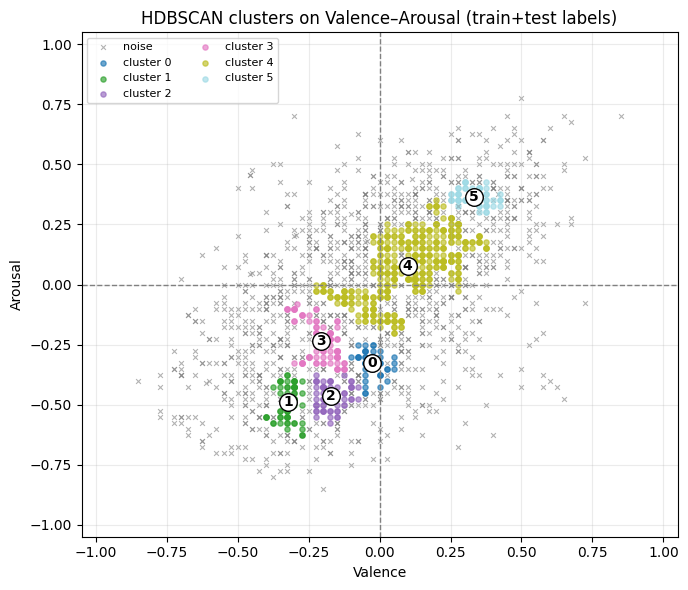

In [42]:
fig, ax = plt.subplots(figsize=(7, 6))

X_all_orig = scaler.inverse_transform(X_all)  # back to [-1, 1] valence/arousal

# plot noise as grey crosses
noise_mask = labels_all == -1
if noise_mask.any():
    ax.scatter(
        X_all_orig[noise_mask, 0],
        X_all_orig[noise_mask, 1],
        s=12,
        marker="x",
        alpha=0.6,
        linewidths=0.8,
        color="gray",
        label="noise",
    )

# color clusters
cmap = plt.get_cmap("tab20", max(1, uniq_cls.size))
for i, cid in enumerate(sorted(uniq_cls)):
    m = labels_all == cid
    ax.scatter(
        X_all_orig[m, 0],
        X_all_orig[m, 1],
        s=14,
        alpha=0.65,
        label=f"cluster {cid}",
        color=cmap(i),
    )

    # draw center + id in original space
    c = cluster_report_pl.filter(pl.col("cluster_id") == cid)
    cv_std = float(c["center_valence"][0])
    ca_std = float(c["center_arousal"][0])
    cv, ca = scaler.inverse_transform([[cv_std, ca_std]])[0]
    ax.scatter(
        [cv], [ca], s=160, edgecolor="black", facecolor="white", marker="o", zorder=5
    )
    ax.text(
        cv, ca, f"{cid}", fontsize=10, weight="bold", ha="center", va="center", zorder=6
    )

ax.axvline(0, color="gray", lw=1, ls="--")
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel("Valence")
ax.set_ylabel("Arousal")
ax.set_title("HDBSCAN clusters on Valence–Arousal (train+test labels)")
ax.grid(alpha=0.25)
ax.legend(loc="best", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()
# Over-engineering: invert scaling on the fly to avoid duplicating precomputed centers.


# Why Cluster First?

> Why aren't we just matching fused V/A with songs directly?

+ **Robustness to noise**: Gating focuses the search on a plausible mood region, so small V/A jitters don’t jump across the whole catalog. It handles uncertainty naturally (top-1 vs top-2) and reduces erratic flips compared to global k-NN.

+ **Interpretability**: “We’re in Calm+Positive station now” is easy to show on a V/A plot with cluster ellipses. It’s a clean, explainable bridge from emotion space to music selection.  

+ **Efficient and scalable**: Restricting to one/two clusters shrinks the candidate set dramatically. Today it’s fast anyway; tomorrow (bigger catalogs) this keeps latency low without changing the logic. If you have millions of songs, instead of computing similarity against all of them, you:

  + Use the GMM to identify the most relevant cluster(s)
  + Only search within that much smaller subset
  + Dramatically reduce computational complexity


# Runtime

+ GMM as “station gate”: Use your fitted StandardScaler + GaussianMixture from the notebook to assign the fused V/A to the most likely cluster via predict_proba.
+ Soft gate when unsure: If the top posterior is low (e.g., < 0.55), widen to top-2 clusters.
+ Rank within cluster: Linear-scan k-NN by Euclidean distance between the stabilized V/A and each song’s V/A; pick top-1 (or top-N for variety).
+ Catalog: Load the persisted `data/DEAM/deam_gmm_clusters.csv` so UI code gets artist/title metadata alongside clusters.

+ GMM “station gate”: Think of the V/A plane like a radio dial. Each Gaussian component is a “station” (an elliptical region). For a new fused V/A point, the GMM tells you which station you’re “tuned to.” You then only search songs inside that station instead of the whole dial.  

+ Top posterior: The GMM returns a probability per station for your point (via predict_proba). The highest of these is the “top posterior” — a simple confidence score for “we’re in station k.” High = commit to that station; middling = consider 2 stations; very low = maybe don’t switch yet.


In [43]:
from pathlib import Path
import numpy as np
import polars as pl

catalog_csv = Path("../../data/DEAM/deam_gmm_clusters.csv")
if catalog_csv.exists():
    deam_songs = pl.read_csv(catalog_csv)
else:
    X_all = merged_genres.select(["valence_ref", "arousal_ref"]).to_numpy()
    X_all_std = scaler.transform(X_all)
    clusters_all = gm.predict(X_all_std)
    proba_all = gm.predict_proba(X_all_std)
    cluster_conf = proba_all.max(axis=1)

    deam_songs = merged_genres.select(
        "song_id", "valence_ref", "arousal_ref", "artist", "song_title", "genre"
    ).with_columns(
        [
            pl.Series("cluster", clusters_all),
            pl.Series("cluster_conf", cluster_conf),
        ]
    )
    print("Catalog CSV missing; rebuilt from merged_genres for this session.")

deam_songs.head()
# Over-engineering: prefer persisted CSV so front-end consumes richer metadata while keeping local rebuild fallback.


valence_ref,arousal_ref,genre,cluster,cluster_conf,song_id,artist,song_title
f64,f64,str,i64,f64,i64,str,str
-0.475,-0.5,"""blues/soul""",1,0.937552,2,"""The New Mystikal Troubadours""","""Tonight A Lonely Century"""
-0.375,-0.425,"""blues/soul""",1,0.855982,3,"""Kevin MacLeod""","""DD Groove"""
0.175,0.125,"""blues/soul""",2,0.859462,4,"""Kevin MacLeod""","""Slow Burn"""
-0.15,0.075,"""blues/soul""",3,0.650001,5,"""My Bubba & Mi""","""Nothing Much"""
0.2,0.35,"""blues/soul""",2,0.555054,7,"""Kevin MacLeod""","""Hustle"""


In [44]:
# Persist DEAM song table for inference
from pathlib import Path

songs_table_path = Path("artifacts/deam_gmm/deam_songs.parquet")
songs_table_path.parent.mkdir(parents=True, exist_ok=True)

deam_songs.write_parquet(str(songs_table_path))
print(f"Saved DEAM songs → {songs_table_path}")


Saved DEAM songs → artifacts/deam_gmm/deam_songs.parquet


In [45]:
# Simple GMM-gated song selector (no dwell/memory)
from pathlib import Path
from typing import Any, Dict
import numpy as np
import polars as pl


def _gate_clusters(v_ref: float, a_ref: float, *, p_top1: float = 0.55) -> np.ndarray:
    """Return top-1 cluster if confident, else top-2, based on posterior."""
    x_std = scaler.transform(np.array([[v_ref, a_ref]]))
    p = gm.predict_proba(x_std)[0]
    order = np.argsort(p)[::-1]
    return order[:1] if p[order[0]] >= p_top1 else order[:2]


def recommend_song_from_va(
    v_ref: float,
    a_ref: float,
    songs: pl.DataFrame,
    *,
    top_k: int = 20,
    p_top1: float = 0.55,
) -> Dict[str, Any]:
    """Pick nearest song in gated cluster(s) by Euclidean distance in [-1, 1]."""
    clusters = _gate_clusters(v_ref, a_ref, p_top1=p_top1).tolist()
    cand = songs.filter(pl.col("cluster").is_in(clusters))
    if cand.height == 0:
        cand = songs

    cand = cand.with_columns(
        (
            (
                (pl.col("valence_ref") - v_ref) ** 2
                + (pl.col("arousal_ref") - a_ref) ** 2
            )
            ** 0.5
        ).alias("dist")
    ).sort("dist")

    top = cand.head(top_k)
    best = top.head(1).to_dicts()[0]

    # Placeholder: map song_id to local file path (adjust to actual folder layout)
    def song_path_from_id(song_id: str | int) -> str:
        # TODO: update to your actual DEAM audio location / naming scheme
        return f"data/deam/audio/{song_id}.mp3"

    best["path"] = song_path_from_id(best["song_id"])
    return best


# Example usage — replace with your stabilized fusion outputs:
v_fused, a_fused = 0.05, -0.10  # reference [-1, 1]
selected = recommend_song_from_va(v_fused, a_fused, deam_songs, top_k=20, p_top1=0.55)
selected


{'valence_ref': 0.050000000000000044,
 'arousal_ref': -0.10000000000000009,
 'genre': 'hip-hop',
 'cluster': 2,
 'cluster_conf': 0.44416659545826676,
 'song_id': 1541,
 'artist': 'Broke For Free',
 'song_title': 'If',
 'dist': 9.309503074677274e-17,
 'path': 'data/deam/audio/1541.mp3'}

In [46]:
# Persist GMM station gate artifacts for inference
from pathlib import Path
import joblib

artifacts_dir = Path("artifacts/deam_gmm")
artifacts_dir.mkdir(parents=True, exist_ok=True)

scaler_path = artifacts_dir / "scaler.pkl"
gmm_path = artifacts_dir / "gmm.pkl"
joblib.dump(scaler, scaler_path)
joblib.dump(gm, gmm_path)
print(f"Saved scaler → {scaler_path}")
print(f"Saved GMM → {gmm_path}")


Saved scaler → artifacts/deam_gmm/scaler.pkl
Saved GMM → artifacts/deam_gmm/gmm.pkl
